# Comparing VaR Methods: Historical, Parametric, Monte Carlo

In this notebook three different approaches to estimating Value-at-Risk (VaR) are compared:

1. Historical Simulation
2. Parametric (Gaussian) VaR
3. Monte Carlo Simulation

Included:
- Build a simple 4-asset portfolio
- Compute 95% 5-day VaR using all three methods
- Compare results in a table and a visualization
- Examine the convergence of the Monte Carlo and Parametric methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from src.var_methods import historical_var, parametric_var, monte_carlo_var

## Load Data
The same four assets are used: SPY, BND, GLD, QQQ

In [2]:
tickers = ["SPY", "BND", "GLD", "QQQ"]
data = pd.read_csv(
    "../data/sample_prices.csv",
    index_col=0,
    parse_dates=[0],
    date_parser=lambda x: pd.to_datetime(x, format="%d/%m/%Y")
)
log_returns = np.log(data / data.shift(1)).dropna()

log_returns.head()

,BND,GLD,QQQ,SPY
Date,,,,
2020-01-03,0.003566,0.013181,-0.009202,-0.007601
2020-01-06,-0.001187,0.010435,0.006423,0.003808
2020-01-07,-0.000832,0.003927,-0.000139,-0.002816
2020-01-08,-0.001547,-0.007530,0.007488,0.005315
2020-01-09,0.001190,-0.005668,0.008438,0.006758


## Compute VaR Estimates
- Horizon: 5 days
- Confidence: 95%
- Portfolio: Equal weights, $1,000,000 value

In [3]:
weights = np.array([0.25, 0.25, 0.25, 0.25])
portfolio_value = 1_000_000
alpha = 0.05
horizon = 5

hist_var = historical_var(log_returns, weights, alpha=alpha, horizon=horizon, portfolio_value=portfolio_value)
param_var = parametric_var(log_returns, weights, alpha=alpha, horizon=horizon, portfolio_value=portfolio_value)
mc_var = monte_carlo_var(log_returns, weights, alpha=alpha, horizon=horizon, sims=10000, portfolio_value=portfolio_value, seed=42)

results = pd.DataFrame({
    "Method": ["Historical", "Parametric (Gaussian)", "Monte Carlo"],
    "VaR (95%, 5-day)": [hist_var, param_var, mc_var]
})
results

,Method,"VaR (95%, 5-day)"
0,Historical,25626.430118
1,Parametric (Gaussian),28938.742377
2,Monte Carlo,29671.073844


## Visual Comparison
Plotting the VaR estimates side by side.

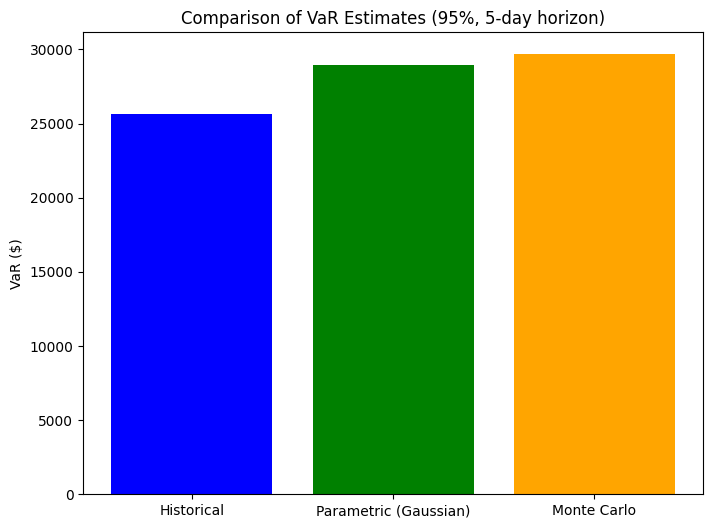

In [4]:
plt.figure(figsize=(8,6))
plt.bar(results["Method"], results["VaR (95%, 5-day)"], color=["blue", "green", "orange"])
plt.ylabel("VaR ($)")
plt.title("Comparison of VaR Estimates (95%, 5-day horizon)")
plt.show()

## Quantitative Comparison
Calculating the deviation of the other methods, using Parametric VaR as a benchmark.

In [6]:
benchmark = param_var

hist_diff = 100 * (hist_var - benchmark) / benchmark
mc_diff = 100 * (mc_var - benchmark) / benchmark

metrics = pd.DataFrame({
    "Method": ["Historical", "Monte Carlo"],
    "VaR ($)": [hist_var, mc_var],
    "Diff vs Parametric (%)": [hist_diff, mc_diff]
})
metrics

,Method,VaR ($),Diff vs Parametric (%)
0,Historical,25626.430118,-11.445944
1,Monte Carlo,29671.073844,2.530626


## Monte Carlo Converges with more Simulations ## 

- With additional simulations the Monte Carlo VaR becomes increasingly similar to the Parametric VaR
- The same random seed and data is used in every case, only the simulation number is varied
- Both methods estimate the same quartile of a Normal / Guassian distribution
- Therefore as simulation number increases, sampling error should vanish (under the law of large numbers), leading to convergence 

In [7]:
sims_list = [1000, 5000, 10000, 20000, 50000]
mc_results = []

for s in sims_list:
    val = monte_carlo_var(log_returns, weights, alpha=alpha, horizon=horizon, sims=s, portfolio_value=portfolio_value, seed=42)
    mc_results.append(val)

mc_df = pd.DataFrame({
    "Simulations": sims_list,
    "Monte Carlo VaR": mc_results
})
mc_df["Diff vs Parametric (%)"] = 100 * (mc_df["Monte Carlo VaR"] - benchmark) / benchmark
mc_df

,Simulations,Monte Carlo VaR,Diff vs Parametric (%)
0,1000,30103.402260,4.024570
1,5000,29849.506388,3.147214
2,10000,29671.073844,2.530626
3,20000,29185.548773,0.852858
4,50000,29051.220753,0.388677


## Summary
- Historical VaR: purely data-driven with no assumptions (besides past performance being representative).
- Parametric VaR: quick, but assumes normality.
- Monte Carlo VaR: flexible and incorporates covariance, but computationally expensive.

The differences highlight why risk managers often use several methods together for robustness.